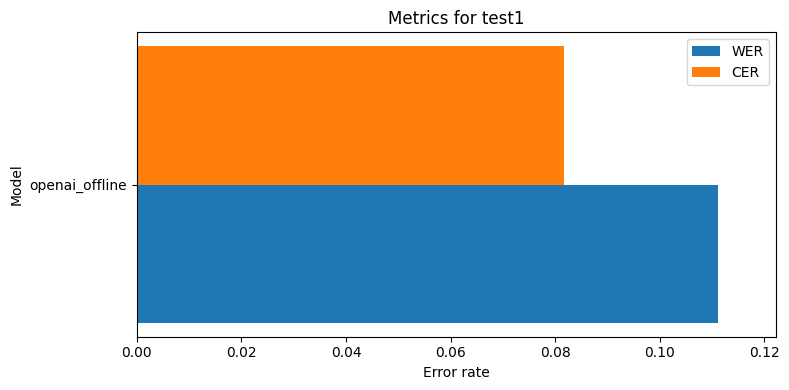

In [3]:
# Multi-model transcription and metrics UI
from pathlib import Path

from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from fastApi.diff_html import build_colored_diff_html
from scripts.notebook_logic import (
    execute_transcription_workflow,
    list_input_files,
    resolve_audio_path,
    resolve_reference,
)

# Prepare folders and file lists
base_dir = Path('.')  # notebook located in backend/ so '.' is backend/
inputs_dir = base_dir / 'inputs'
outputs_dir = base_dir / 'outputs'
inputs_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)
audio_exts = ['.wav', '.mp3', '.m4a']
audio_files, text_files = list_input_files(inputs_dir, audio_exts)

# Widgets: choose audio file from existing files or provide path
audio_dropdown = widgets.Dropdown(options=['--choose--'] + audio_files, description='Recording:')
audio_path_text = widgets.Text(placeholder='Or paste full path to audio file (e.g. in inputs/)', description='Audio path:', layout=widgets.Layout(width='600px'))

# Reference text selection
ref_dropdown = widgets.Dropdown(options=['--choose--'] + text_files, description='Reference:')
ref_textarea = widgets.Textarea(placeholder='Or paste reference text here', description='Ref text:', layout=widgets.Layout(width='600px', height='120px'))

# Model toggles (checkboxes)
models = {
    'amazon': widgets.Checkbox(False, description='Amazon'),
    'google': widgets.Checkbox(False, description='Google'),
    'azure': widgets.Checkbox(False, description='Azure'),
    'openai_online': widgets.Checkbox(False, description='OpenAI online'),
    'openai_offline': widgets.Checkbox(False, description='OpenAI offline (local)')
}

run_button = widgets.Button(description='Run selected models', button_style='primary')
output = widgets.Output(layout={'border': '1px solid gray'})

# Display widgets for resolved reference and model outputs
reference_preview = widgets.Textarea(
    value='',
    description='Reference (normalized):',
    disabled=True,
    layout=widgets.Layout(width='100%', height='140px')
)
model_outputs_container = widgets.VBox([])

ui = widgets.VBox([
    audio_dropdown,
    audio_path_text,
    ref_dropdown,
    ref_textarea,
    widgets.HBox(list(models.values())),
    run_button,
    output,
    widgets.HTML('<b>Reference text used for metrics (no punctuation, lowercase)</b>'),
    reference_preview,
    widgets.HTML('<b>Transcriptions by selected model (no punctuation, lowercase)</b>'),
    model_outputs_container
])
display(ui)

# When run button is clicked
def on_run_clicked(_):
    with output:
        output.clear_output()
        reference_preview.value = ''
        model_outputs_container.children = tuple()

        ap = resolve_audio_path(audio_path_text.value, audio_dropdown.value, inputs_dir)
        ref = resolve_reference(ref_textarea.value, ref_dropdown.value, base_dir, inputs_dir)
        if not ap:
            print('Please select or provide an audio file path')
            return
        if not ref:
            print('Please select or provide a reference text')
            return

        selected_models = [key for key, chk in models.items() if chk.value]
        if not selected_models:
            print('Please select at least one model')
            return

        print('Audio:', ap)
        print('Reference:', ref)
        print('Metrics mode: normalized (no punctuation, lowercase)')

        try:
            workflow = execute_transcription_workflow(ap, ref, selected_models, outputs_dir)
        except Exception as e:
            print('Workflow failed:', e)
            return

        reference_text = workflow['reference_text']
        basename = workflow['basename']
        results = workflow['results']

        reference_preview.value = reference_text

        model_output_widgets = []
        for key in selected_models:
            model_result = results.get(key, {'text': '', 'wer': None, 'cer': None})
            txt = model_result['text']
            w = model_result['wer']
            c = model_result['cer']

            print(f'Running {key}...')
            if w is None or c is None:
                print('Failed computing metrics for', key)
            else:
                print(f'Metrics for model: {key} (normalized text)')
                print(f'WER: {w}')
                print(f'CER: {c}')

            model_output_widgets.append(
                widgets.VBox([
                    widgets.Textarea(
                        value=txt if txt else '[empty transcription]',
                        description=f'{key}:',
                        disabled=True,
                        layout=widgets.Layout(width='100%', height='110px')
                    ),
                    widgets.HTML(value=build_colored_diff_html(reference_text, txt, key))
                ])
            )

        if model_output_widgets:
            model_outputs_container.children = tuple(model_output_widgets)
        else:
            model_outputs_container.children = (widgets.Label('No model outputs were produced.'),)

        # After loop, plot results for selected models
        if results:
            keys = list(results.keys())
            wers = [results[k]['wer'] if results[k]['wer'] is not None else np.nan for k in keys]
            cers = [results[k]['cer'] if results[k]['cer'] is not None else np.nan for k in keys]

            fig, ax = plt.subplots(figsize=(8, 4))
            y = np.arange(len(keys))
            bar_h = 0.35

            ax.barh(y - bar_h / 2, wers, height=bar_h, label='WER')
            ax.barh(y + bar_h / 2, cers, height=bar_h, label='CER')

            ax.set_yticks(y)
            ax.set_yticklabels(keys)
            max_val = max([v for v in wers + cers if not np.isnan(v)] + [0.01])
            ax.set_xlim(0, max_val * 1.1)
            ax.set_xlabel('Error rate')
            ax.set_ylabel('Model')
            ax.set_title(f'Metrics for {basename}')
            ax.legend()
            plt.tight_layout()
            display(fig)
        else:
            print('No models were selected or no results produced')

run_button.on_click(on_run_clicked)